# EDA для TMDB Movies Dataset

**Бизнес-контекст:** Сайт для поиска фильмов "TMDB" хочет повысить конверсию своего каталога.  
Гипотеза: постер, по которому точно понятен жанр, формирует правильные ожидания у зрителя, а значит зритель не будет разочарован и поставит более высокую оценку.  

**Две ML-задачи:**
- **Табличная (FCN):** предсказание рейтинга фильма по метаданным
- **CV (CNN/ViT):** оценка соответствия постера жанру и выявление фильмов с непонятными постерами

**Цель этого ноутбука:** понять данные, проверить базовые гипотезы, подготовить данные к обучению моделей.

## 0. Импорты

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from pathlib import Path

## 1. Загрузка данных

In [49]:
df = pd.read_csv("../data/raw/TMDB_movie_dataset_v11.csv")
df.head(3)

,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,original_title,overview,popularity,poster_path,tagline,genres,production_companies,production_countries,spoken_languages,keywords
0,27205,Inception,8.364,34495,Released,2010-07-15,825532764,148,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,...,Inception,"Cobb, a skilled thief who commits corporate es...",83.952,/oYuLEt3zVCKq57qu2F8dT7NIa6f.jpg,Your mind is the scene of the crime.,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc..."
1,157336,Interstellar,8.417,32571,Released,2014-11-05,701729206,169,False,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,...,Interstellar,The adventures of a group of explorers who mak...,140.241,/gEU2QniE6E77NI6lCU6MxlNBvIx.jpg,Mankind was born on Earth. It was never meant ...,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English,"rescue, future, spacecraft, race against time,..."
2,155,The Dark Knight,8.512,30619,Released,2008-07-16,1004558444,152,False,/nMKdUUepR0i5zn0y1T4CsSB5chy.jpg,...,The Dark Knight,Batman raises the stakes in his war on crime. ...,130.643,/qJ2tW6WMUDux911r6m7haRef0WH.jpg,Welcome to a world without rules.,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin","joker, sadism, chaos, secret identity, crime f..."


In [50]:
df.shape

(1437247, 24)

In [51]:
df.columns

Index(['id', 'title', 'vote_average', 'vote_count', 'status', 'release_date',
       'revenue', 'runtime', 'adult', 'backdrop_path', 'budget', 'homepage',
       'imdb_id', 'original_language', 'original_title', 'overview',
       'popularity', 'poster_path', 'tagline', 'genres',
       'production_companies', 'production_countries', 'spoken_languages',
       'keywords'],
      dtype='object')

Получается 1437247 строк и 24 колонки

Проверим на дубли в данных

In [52]:
df.duplicated().sum()

np.int64(381)

Оставим только первые записи

In [53]:
mask = df.duplicated(keep='first')
df = df[~mask].reset_index()

df.duplicated().sum()

np.int64(0)

Проверим на всякий случай также на дублирование по id 

In [54]:
df.duplicated(subset=['id']).sum()

np.int64(884)

Попробуем для примера посмотреть на конкретные id, встречающиеся более 1 раза

In [55]:
counted = df['id'].value_counts().reset_index()
counted[counted['count'] > 1]


,id,count
0,1525030,4
1,1523440,3
2,1307431,2
3,1220680,2
4,1233010,2
...,...,...
876,1498517,2
877,1495757,2
878,1495164,2
879,1496828,2


In [56]:
df[df['id'] == 1525030]

,index,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,...,original_title,overview,popularity,poster_path,tagline,genres,production_companies,production_countries,spoken_languages,keywords
825450,825828,1525030,Detective Kibbles: Part 2 | Remastered,0.0,0,Released,NaN,0,0,False,...,Detective Kibbles: Part 2 | Remastered,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
825454,825832,1525030,Detective Kibbles: Part 2 | Remastered,0.0,0,Released,2025-08-04,0,10,False,...,Detective Kibbles: Part 2 | Remastered,"After a brutal attack in his own home, Detecti...",0.0289,/74SKZslJiJrO1nK4LnFa7ztesxZ.jpg,Every hero must have an end.,"Crime, Comedy, Drama",MattMigFilms,NaN,English,"police, detective, drama, kibbles"
825455,825833,1525030,Detective Kibbles: Part 2 | Remastered,0.0,0,Released,2025-08-04,0,10,False,...,Detective Kibbles: Part 2 | Remastered,"After a brutal attack in his own home, Detecti...",0.0286,/74SKZslJiJrO1nK4LnFa7ztesxZ.jpg,Every hero must have an end.,"Crime, Comedy, Drama",MattMigFilms,NaN,English,"police, detective, drama, kibbles"
825456,825834,1525030,Detective Kibbles: Part 2 | Remastered,0.0,0,Released,2025-08-04,0,10,False,...,Detective Kibbles: Part 2 | Remastered,"After a brutal attack in his own home, Detecti...",0.0218,/74SKZslJiJrO1nK4LnFa7ztesxZ.jpg,Every hero must have an end.,"Crime, Comedy, Drama",MattMigFilms,NaN,English,"police, detective, drama, kibbles"


In [57]:
df['status'].unique()

array(['Released', 'Planned', 'Post Production', 'In Production',
       'Rumored', 'Canceled'], dtype=object)

In [58]:
df['adult'].unique()

array([False,  True])

Далее посмотрим на типы данных в датасете и наличие пропусков

In [60]:
missing = df.isnull().sum()
missing[missing > 0].sort_values(ascending=False)

homepage                1289470
tagline                 1236342
keywords                1083290
backdrop_path           1081522
production_companies     827308
imdb_id                  764952
production_countries     698406
spoken_languages         670919
genres                   634264
poster_path              513635
overview                 331128
release_date             324097
release_date_dt          324097
original_title               19
title                        19
dtype: int64

Это пропуски в абсолютных числах, далее выведем в процентах для наглядности

In [61]:
missing_count = missing[missing > 0].sort_values(ascending=False)
missing_count / 1437247 * 100

homepage                89.718051
tagline                 86.021540
keywords                75.372570
backdrop_path           75.249557
production_companies    57.561992
imdb_id                 53.223419
production_countries    48.593318
spoken_languages        46.680842
genres                  44.130480
poster_path             35.737420
overview                23.039046
release_date            22.549847
release_date_dt         22.549847
original_title           0.001322
title                    0.001322
dtype: float64

Поля, связанные с названиями (title и original_title), практически не содержат пропусков (19), при этом id полностью заполняется. vote_average (целевая переменная) в таблицу вообще не попал, а значит, что пропусков в нем нет пропусков.

Для нашей первой бизнес-задачи по предсказанию рейтингов фильмов по их метаданным важны сами метаданные. И с некоторыми из них есть проблемы. В release_date и genres 22.6 и 44.1% пропусков соответственно. Это значит, что в случае работы с жанрами нам придется либо вырезать почти половину фильмов, либо придумать какую-то хитрую обработку для них. Примерно такая же ситуация и с production_companies и production_countries. В keywords, tagline и homepage пропусков более 75%, эти атрибуты не несут практической значимости для нашей задачи, поэтому можно эти столбцы удалить.

Для второй бизнес-задачи по выявлению жанра по постеру, ее ключевые поля poster_path пропущены у 35.8% и 44.1% строк, надо посмотреть на пересечение по заполняемости именно этих атрибутов.

## 2. Предобработка: извлечение жанров

Проверим, в каком формате у нас в таблице хранятся жанры

In [62]:
df["genres"].info

<bound method Series.info of 0                   Action, Science Fiction, Adventure
1                    Adventure, Drama, Science Fiction
2                       Drama, Action, Crime, Thriller
3          Action, Adventure, Fantasy, Science Fiction
4                   Science Fiction, Action, Adventure
                              ...                     
1436861                                            NaN
1436862                                          Drama
1436863                                          Drama
1436864                          Crime, Drama, Romance
1436865                                    Documentary
Name: genres, Length: 1436866, dtype: object>

Обычные строки текста, которые надо превратить их в список строк. Применим one-hot encoding, чтобы иметь метки всех возможных жанров фильма. В дальнейшем в cv модели в качестве MVP будем предсказывать единственный жанр и смореть на пересечние по всем бинарным столбцам по фильму

In [63]:
all_genres = df["genres"].fillna('').str.split(', ').explode().unique()
df['genres_list'] = df['genres'].fillna('').str.split(', ')

for genre in all_genres:
    df[f'genre_{genre}'] = df['genres_list'].apply(lambda x: 1 if genre in x else 0)

df.head(3)


,index,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,...,genre_Mystery,genre_War,genre_Animation,genre_Family,genre_Horror,genre_Music,genre_History,genre_TV Movie,genre_Documentary,genre_
0,0,27205,Inception,8.364,34495,Released,2010-07-15,825532764,148,False,...,0,0,0,0,0,0,0,0,0,0
1,1,157336,Interstellar,8.417,32571,Released,2014-11-05,701729206,169,False,...,0,0,0,0,0,0,0,0,0,0
2,2,155,The Dark Knight,8.512,30619,Released,2008-07-16,1004558444,152,False,...,0,0,0,0,0,0,0,0,0,0


## 3. Целевая переменная: рейтинг

In [66]:
genre_cols = [col for col in df.columns if col.startswith('genre_')]

df_clean = df[
    (df['vote_count'] >= 50) &
    (df['vote_average'] > 0) &
    df['vote_average'].notna() &
    df['vote_count'].notna() &
    df[genre_cols].any(axis=1) &   
    df['poster_path'].notna()
]

len(df_clean)

27963

После фильтрации, в новой очищенной таблице осталось 27963 фильма. Фильтрация следующая: количество оценок не менее 50, чтобы каждый голос не имел сильно большой вес, так как если отзывов мало, то один отличный или откровенно негативный отзыв уже ощутимо повлияет на среднюю оценку фильма, плюс просто отсеиваем ноунеймов. Средняя оценка просто должна быть и быть больше нуля. Точно так же, как и поля с оценками, жанром и ссылкой на постер просто должны быть.

Важно помнить, что при такой фильтрации скорее всего в выборке останутся более популярные фильмы и в таком случае отсеятся наиболее популярные жанры (или неспецифичные), поэтому при анализе модели важно помнить, что она обучалась на смещенной выборке и будет хорошо работать именно на популярных проектах.

In [67]:
df_clean['vote_average'].describe()

count    27963.000000
mean         6.408983
std          0.881636
min          1.840000
25%          5.858000
50%          6.473000
75%          7.024000
max          9.980000
Name: vote_average, dtype: float64

Медиананная оценка - 6,47. 6,5 если округлять.

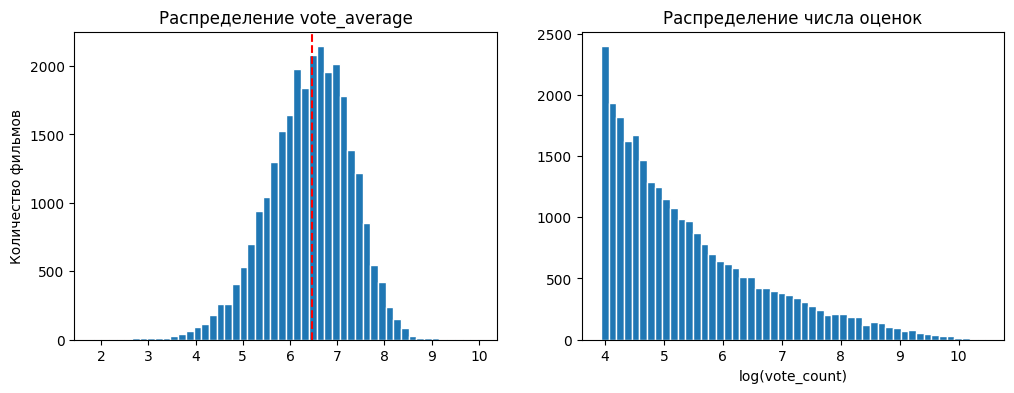

In [71]:
median_rating = df_clean['vote_average'].median()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_clean['vote_average'], bins=50, edgecolor='white')
axes[0].axvline(median_rating, linestyle='--', color="red")
axes[0].set_title('Распределение vote_average')
axes[0].set_ylabel('Количество фильмов')

axes[1].hist(np.log1p(df_clean['vote_count']), bins=50, edgecolor='white')
axes[1].set_title('Распределение числа оценок')
axes[1].set_xlabel('log(vote_count)')

plt.savefig('../data/processed/eda_rating_distribution.png')
plt.show()

Распределение рейтинга близко практически симметрично. Медиана составляет 6,5, а стандартное отклонение 0,88, . Это означает, что оценки большинства фильмов сконцентрированы в диапазоне 5,5-7,5, а экстремальные значения (ниже 4 и выше 8,5) встречаются редко. Это хорошо для регрессии, потому что целевая переменная не потребует преобразования.

Судить о средней оценке фильма можно только в привязке к количеству оценок. По сути показывать пользователю рейтинг без числа голосов рядом просто некорректно. Собственно поэтому мы и отсекли фильмы, где оценок менее 50.

Распределение числа оценок сильно скошено вправо даже после логарифмирования. Большинство фильмов имеют 50-200 оценок, а высокая популярность, где голосов тысячи встречается редко. Распределение похоже на экспоненциальное

Хоть регрессия это и хорошо, но надо прикинуть, что будет, если в табличной задаче применять классификаци. И в первую очередь надо понять, что для нас будет значить хороший фильм, а что плохой. За хороший фильм возьмем топ 30% рейтинга

In [72]:
threshold = df_clean['vote_average'].quantile(0.70)
df_clean['is_high_rated'] = (df_clean['vote_average'] >= threshold).astype(int)

threshold

C:\Users\Windows\AppData\Local\Temp\ipykernel_15152\2757165551.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['is_high_rated'] = (df_clean['vote_average'] >= threshold).astype(int)


np.float64(6.903)

С порога 6.9 начинается высокий рейтинг

P.S. Дописываю после написания раздела по табличным данным.

В ходе EDA оставались сомнения, что предсказывать - среднюю оценку фильма или просто хороший он или плохой. Но с точки зрения полезности для бизнеса, в итоге было принято решение предсказывать именно саму оценку.

## 4. Анализ жанров

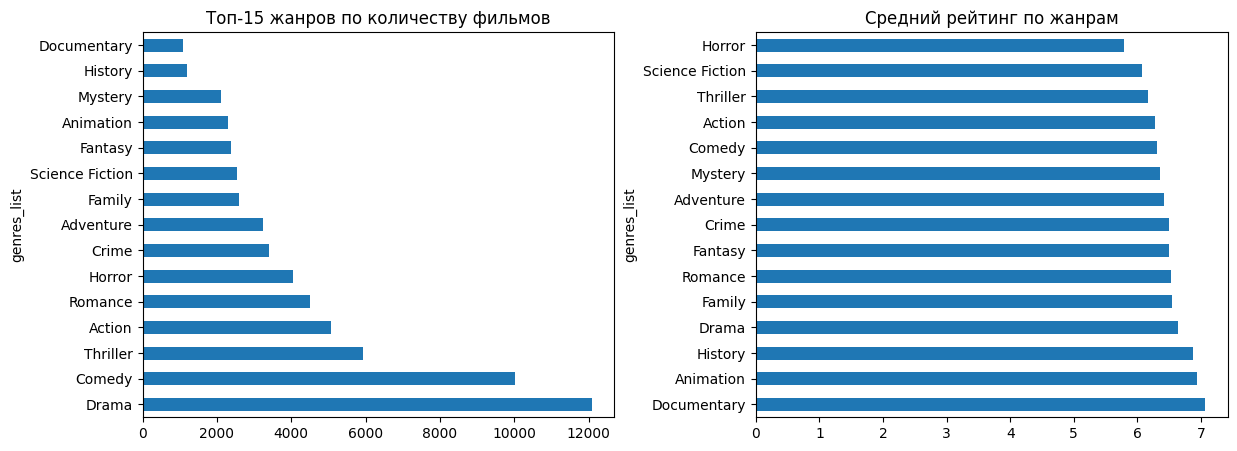

In [77]:
genres = df_clean.explode('genres_list')

genre_counts = genres['genres_list'].value_counts()
top_genres = genre_counts.head(15).index

sorted = genres[genres['genres_list'].isin(top_genres)]
                

genre_ratings = sorted.groupby('genres_list')['vote_average'].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

genre_counts.head(15).plot(kind='barh', ax=axes[0])
axes[0].set_title('Топ-15 жанров по количеству фильмов')

genre_ratings.plot(kind='barh', ax=axes[1])
axes[1].set_title('Средний рейтинг по жанрам')

plt.subplots_adjust(wspace=0.3)
plt.savefig('../data/processed/eda_genre_analysis.png')
plt.show()

График по топ-15 жанрам по количеству фильмов показывает, что драмы и комедии гораздо распространеннее остальных жанров. Вместе они составляют почти половину всех фильмов в датасете. Значит в задаче по табличным данным жанр как признак будет сильно смещен в сторону этих двух категорий.

График по среднему рейтингу по жанрам дает интересную картину. Оказывается, что самые популярные жанры вообще не самые высоко оцениваемые. Документальные, анимационные и исторические занимают топ-3 по среднему рейтингу, при этом они в хвосте по количеству фильмов. А хорроры - самый низко оцениваемый жанр, несмотря на приличный объём. Драмы и комедии, которые доминируют количественно, держатся чуть выше медианы.

## 5. Анализ числовых признаков

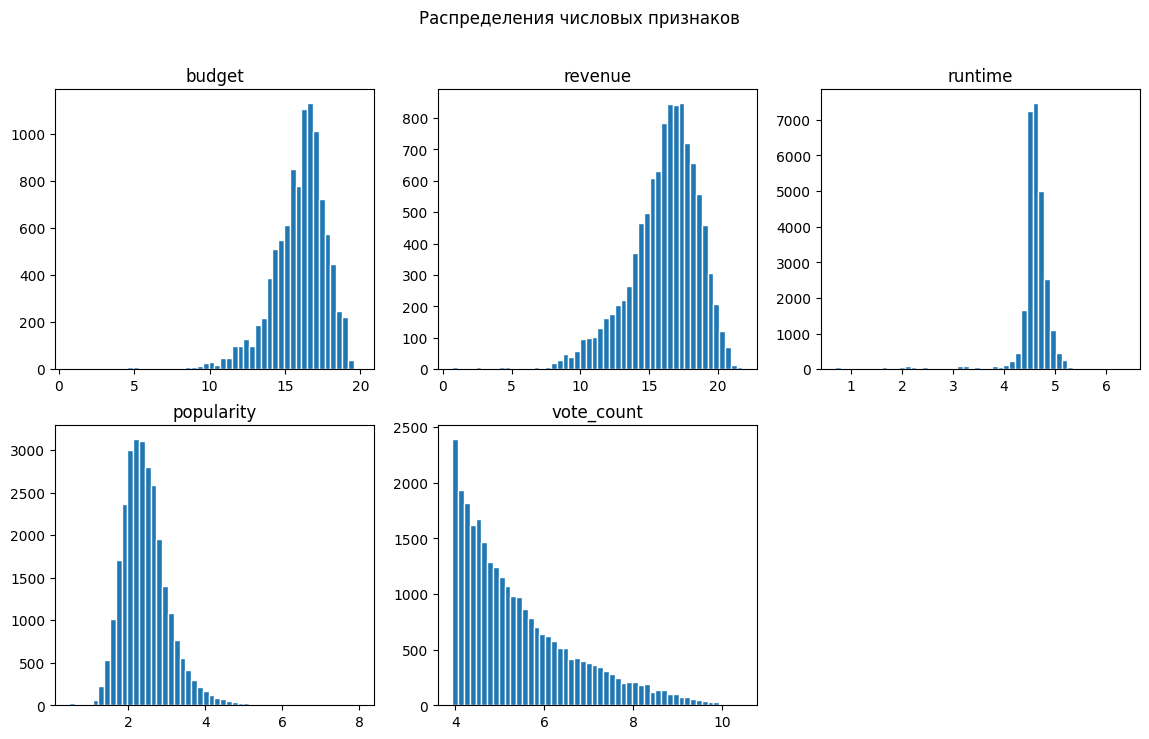

In [78]:
numeric_features = ['budget', 'revenue', 'runtime', 'popularity', 'vote_count']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    data = df_clean.loc[df_clean[col] > 0, col]
    axes[i].hist(np.log1p(data), bins=50, edgecolor='white')
    axes[i].set_title(col)

axes[-1].axis('off')
plt.suptitle('Распределения числовых признаков')
plt.savefig('../data/processed/eda_numeric_distributions.png')
plt.show()

Бюджет и выручка после логарифмирования показывают близкое к нормальному распределение, но слева находится много фильмов с нулевым или незаполненным бюджетом/сборами. Или просто низкими. Нужно будет решить, что делать с этими строками. Нулевые и незаполненные думаю можно спокойно дропать. Заполнение медианой ничего полезного не даст.

У runtime тоже нормальное распределение. Большинство фильмов длятся в районе log(4,5). Если без логарифма, то это примерно 90 минут. Стандарт. Логарифмировать на самом деле даже не обязательно.

vote_count мы рассмотрели ранее. popularity в принципе тоже показывает экспоненциальный спад, справа тоже есть хвост. Это означает, что без логарифмирования там будут экстремальные выбросы.

Теперь посмотрим насколько разные признаки коррелируют с рейтингом

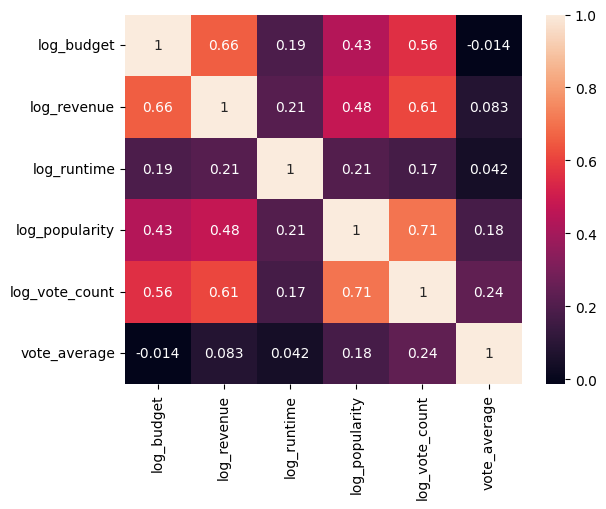

In [79]:
corr_data = df_clean[numeric_features + ['vote_average']].copy()
for col in numeric_features:
    corr_data[f'log_{col}'] = np.log1p(corr_data[col])
log_cols = [f'log_{c}' for c in numeric_features] + ['vote_average']
sns.heatmap(corr_data[log_cols].corr(), annot=True)
plt.savefig('../data/processed/eda_correlation.png')
plt.show()

Корреляция всех числовых признаков с vote_average крайне слабая: максимум у log_vote_count (0.24) и log_popularity (0.18), остальные практически на нуле. log_budget показывает даже слабую отрицательную корреляцию (-0.014), то есть бюджет линейно вообще не связан с рейтингом. Числовые признаки сами по себе слабо предсказывают рейтинг. В рамках решения табличной задачи придется улавливать нелинейные зависимости, и это как раз то в чём нейросети сильнее линейных моделей. Плюс теперь мы можем обосновать выбор именно нейросети, а не линейной регрессии.

При этом между собой признаки коррелируют сильно: log_budget и log_revenue (0.66), log_popularity и log_vote_count (0.71). Имеется мультиколлинеарность.

## 6. Рейтинг по годам

In [81]:
df_clean['year'] = pd.to_datetime(df_clean['release_date']).dt.year

C:\Users\Windows\AppData\Local\Temp\ipykernel_15152\266698433.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['year'] = pd.to_datetime(df_clean['release_date']).dt.year


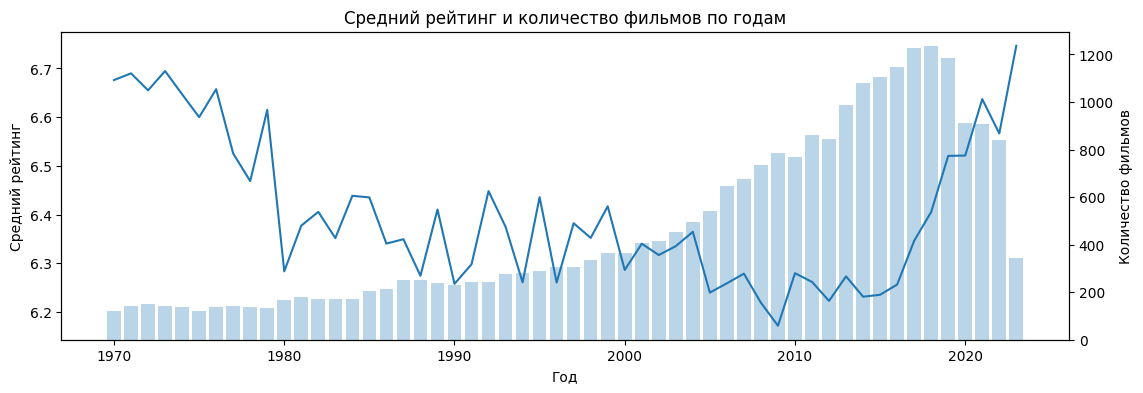

In [82]:
df_yearly = df_clean[df_clean['year'].between(1970, 2024)]

yearly = df_yearly.groupby('year').agg(
        avg_rating=('vote_average', 'mean'),
         n_movies=('vote_average', 'count')
    ).reset_index()

fig, ax1 = plt.subplots(figsize=(13, 4))
ax2 = ax1.twinx()
ax1.set_xlabel('Год')
ax1.set_ylabel('Средний рейтинг')
ax2.set_ylabel('Количество фильмов')
ax1.set_title('Средний рейтинг и количество фильмов по годам')
ax1.plot(yearly['year'], yearly['avg_rating'])
ax2.bar(yearly['year'], yearly['n_movies'], alpha=0.3)
plt.savefig('../data/processed/eda_rating_by_year.png')
plt.show()

До 2010 года средний рейтинг держится в диапазоне 6.2–6.5 с заметной волатильностью, особенно в 70-е и 80-е, когда количество фильмов было небольшим и каждый отдельный фильм сильно влиял на среднее. После 2010 наблюдается устойчивый рост рейтинга вплоть до резкого скачка в 2022–2024, где средний рейтинг достиг 6.7 и выше.

Скорее всего, это не значит, что современные фильмы лучше. Скорее всего тут две причины. Первая - у старых фильмов больше времени накопить оценки, и со временем выживают только те, которые люди помнят и любят. Второй — у очень новых фильмов (2022–2024) ещё мало оценок, несмотря на наш фильтр vote_count >= 50, видимо, первые зрители оказываются более лояльны.

## 7. Манипуляции с жанрами

Соберем датасет конкретно под первую задачу, включим в него только нужные столбцы

In [84]:
df_clean['n_genres'] = df_clean[genre_cols].sum(axis=1)

C:\Users\Windows\AppData\Local\Temp\ipykernel_15152\1071007969.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['n_genres'] = df_clean[genre_cols].sum(axis=1)


In [85]:
base_cols = [
    'id', 'title', 'year', 'runtime', 'budget', 'revenue',
    'popularity', 'vote_count', 'vote_average', 'is_high_rated',
    'n_genres', 'original_language', 'poster_path', 
    'production_companies', 'production_countries'
]

tabular_cols = base_cols + genre_cols

df_tabular = df_clean[tabular_cols]

df_tabular.to_csv('../data/processed/tmdb_clean.csv', index=False)

len(df_tabular)

27963

27943 фильмов мы сохранили

## 8. Ключевая бизнес-гипотеза: постеры и рейтинг

In [88]:
downloaded_posters = set(f.stem for f in Path('../data/raw/posters/downloaded').glob('*.jpg'))
if 'id' in df_clean.columns:
    df_clean['poster_downloaded'] = df_clean['id'].astype(str).isin(downloaded_posters)
len(downloaded_posters)

C:\Users\Windows\AppData\Local\Temp\ipykernel_15152\2924350713.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['poster_downloaded'] = df_clean['id'].astype(str).isin(downloaded_posters)


9685

По факту вот столько постеров мы имеем в папке

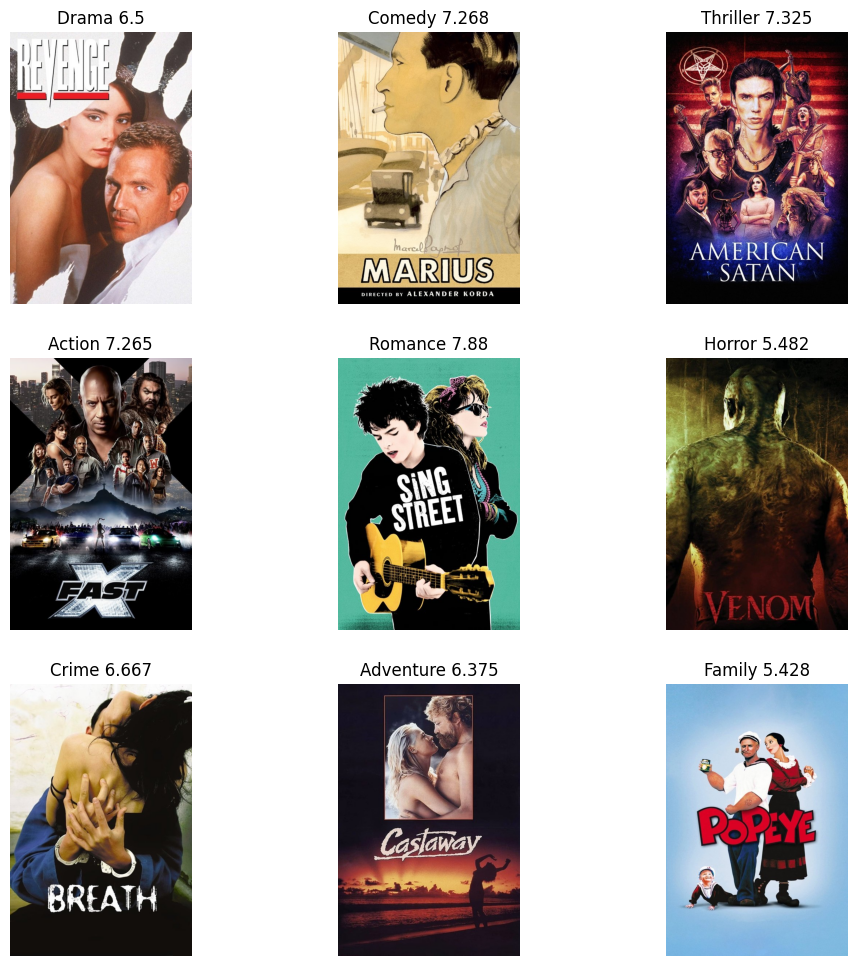

In [89]:
genres = df_clean.explode('genres_list')
top_genres = genre_counts.head(9).index
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.flatten()
for i, genre in enumerate(top_genres):
    movie = genres[
        (genres['genres_list'] == genre) &
        (genres['poster_downloaded'])
    ].sample(1).iloc[0]
    axes[i].imshow(
        mpimg.imread(Path('../data/raw/posters/downloaded') / f"{movie['id']}.jpg")
    )
    axes[i].set_title(genre + " " + str(movie["vote_average"]))
    axes[i].axis('off')
plt.show()